# File 3 - Context Baseline + GCN-DOMINANT Structural Anomaly Detection
### `03_baseline_gnn_anomaly.ipynb`

- **Part A - Global baseline (approach a):** the "what is normal" reference now comes
  from **external context -> an LLM / physiological prior**, not from
  a personal circadian curve. A `SubjectContext` cohort descriptor is built from the
  data + user-supplied fields (age is provided externally: 40 -> `40_49`);
  `establish_baseline` emits the cohort's expected-normal HR/HRV ranges; a
  **deterministic** detector measures each episode's deviation, with the resting/sleep
  band **modulated by temperature** and a **lifestyle tag** (location + weather + activity)
  attached for interpretation.
- **Part B - GCN-DOMINANT (optional, relational view):** an unsupervised,
  reconstruction-based structural anomaly model on the BKG. Kept as a **second,
  independent** detector for relational/transition anomalies the magnitude band misses.
  Node features now include temperature + humidity. Outputs **both** node and edge scores.

**Guardrails enforced here:**
- The baseline is a **per-cohort reference** set by the LLM/prior; the LLM never flags
  individual samples - a deterministic detector does (LLM = ruler, detector =
  measurement; no circularity).
- Context is **external meta-information**: the pipeline stays generic and never decides
  what the context is. Missing fields **widen** the band, never crash.
- `age_band` cannot be predicted from this low-intensity subject's HR, so it is supplied
  **externally** (40 -> `40_49`) - exactly the "context established outside the pipeline"
  principle; this also tightens the band (higher sensitivity).
- Weather modulates the expected band (heat raises resting HR), so a hot-day resting HR
  is not falsely flagged; the same signal enriches the lifestyle interpretation.
- The GCN receives **no LLM anomaly labels** - only structural/physiological features -
  and emits node **and** edge scores.

## 1. Imports & load episodes / graph

In [1]:
import os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

TZ = "Australia/Adelaide"
PROC_DIR = r"C:\Project\Apple Health Data\data\processed"

ep = pd.read_parquet(os.path.join(PROC_DIR, "behavioral_episodes.parquet"))
if ep["datetime"].dt.tz is None:
    ep["datetime"] = ep["datetime"].dt.tz_localize(TZ)
print(f"episodes: {len(ep):,}   rest: {(~ep['is_workout']).sum():,}  workout: {ep['is_workout'].sum():,}")
ep.head(10)

episodes: 104,565   rest: 103,644  workout: 921


,node_id,datetime,avg_hr,max_hr,min_hr,hrv_sdnn,n_samples,is_workout,activity,location_type,weather_temp,weather_humidity,location_place,timestamp_iso
0,0,2017-11-27 10:45:00+10:30,82.000000,82.0,82.0,NaN,1,False,rest,unknown,20.2,48,None,2017-11-27T10:45:00+10:30
1,1,2017-11-27 11:00:00+10:30,73.500000,74.0,72.0,NaN,4,False,rest,unknown,22.8,43,None,2017-11-27T11:00:00+10:30
2,2,2017-11-27 11:15:00+10:30,76.833333,80.0,74.0,NaN,12,False,rest,unknown,22.8,43,None,2017-11-27T11:15:00+10:30
3,3,2017-11-27 11:30:00+10:30,72.222222,76.0,68.0,NaN,9,False,rest,unknown,22.8,43,None,2017-11-27T11:30:00+10:30
4,4,2017-11-27 11:45:00+10:30,73.000000,74.0,72.0,NaN,3,False,rest,unknown,22.8,43,None,2017-11-27T11:45:00+10:30
5,5,2017-11-27 12:00:00+10:30,69.333333,72.0,67.0,NaN,3,False,rest,unknown,24.7,38,None,2017-11-27T12:00:00+10:30
6,6,2017-11-27 12:15:00+10:30,70.000000,72.0,69.0,NaN,3,False,rest,unknown,24.7,38,None,2017-11-27T12:15:00+10:30
7,7,2017-11-27 12:30:00+10:30,71.333333,72.0,70.0,NaN,3,False,rest,unknown,24.7,38,None,2017-11-27T12:30:00+10:30
8,8,2017-11-27 12:45:00+10:30,71.500000,74.0,69.0,NaN,2,False,rest,unknown,24.7,38,None,2017-11-27T12:45:00+10:30
9,9,2017-11-27 13:00:00+10:30,69.250000,70.0,68.0,NaN,4,False,rest,unknown,25.7,36,None,2017-11-27T13:00:00+10:30


## Part A - Context-driven global baseline (approach a)

Replaces the old personal multi-harmonic cosinor. The baseline is now indexed by an
**external `SubjectContext`** and produced by `establish_baseline` (Gemini structured
output when a key is present, else a textbook-physiology fallback: Tanaka HRmax,
Karvonen HR-reserve, age/fitness resting-HR & SDNN tables).

Per-episode we then attach `expected_hr` (band centre), `band_lo/hi`, and a signed
`deviation_z` - the **same Standard-Definitions interface** File 3 Part B and File 4
consume - plus the context-native anomaly flag. Modules live in
`notebooks/context_baseline/`.

In [2]:
import sys
CB_DIR = r"C:\Project\Apple Health Data\notebooks\context_baseline"
if CB_DIR not in sys.path:
    sys.path.insert(0, CB_DIR)
from context_library import SubjectContext, EpisodeContext                  # noqa: E402
from context_providers import build_subject_context, load_frames, attach_weather  # noqa: E402
from global_baseline import (establish_baseline, detect_against_baseline,    # noqa: E402
                             translate)

# --- External subject context (context is provided; pipeline stays generic) ---
# age_band CANNOT be predicted for this subject (low-intensity workouts), so it is
# supplied externally: the subject is 40 -> band "40_49". This tightens the baseline
# (the single biggest sensitivity lever). Set sex too if known.
USER_CONTEXT = {
    "age_band": "40_49",             # subject is 40 (external meta-information)
    "sex": "male",                # "male" | "female" if known
    "health_conditions": "none",     # e.g. "hypertension", "pregnancy", ...
    "goal": "general_health",
    # fitness_level & home_climate are predicted from the data below; override here
    # (e.g. "fitness_level": "recreational") only if the prediction is wrong.
}

frames = load_frames()                                   # real data/processed/*.parquet
# Repair the weather join (File 2 leaves episode weather all-NaN) so temperature +
# humidity feed the band modulation, the lifestyle tag, and the GCN features.
ep = attach_weather(ep, frames.get("weather"))
print(f"weather attached: {ep['weather_temp'].notna().sum():,}/{len(ep):,} episodes "
      f"(mean {ep['weather_temp'].mean():.1f} C)")

est = build_subject_context(frames, user=USER_CONTEXT)
ctx = est.context
print("\nSubject context (external overrides + data-predicted fields):")
print(est.report())
print(f"\ncohort-field coverage: {ctx.coverage():.0%}")

weather attached: 104,565/104,565 episodes (mean 16.9 C)

Subject context (external overrides + data-predicted fields):
  age_band           = 40_49        conf=1.00  [user] user-provided (overrides prediction)
  fitness_level      = recreational conf=0.90  [predicted] resting_HR~74 (non-workout avg_hr p10); chart=average [male 36_45]
  home_climate       = temperate    conf=0.90  [predicted] mean_temp~15.7C, humidity~66%, warm_frac=0.03, home=Gamma Crescent, Panorama
  sex                = male         conf=1.00  [user] user-provided
  health_conditions  = none         conf=1.00  [user] user-provided
  goal               = general_health conf=1.00  [user] user-provided

cohort-field coverage: 100%


In [3]:
# approach (a): the LLM (or offline prior) emits the cohort's expected-normal ranges.
#   "auto"    -> Gemini if GEMINI_API_KEY is found (.env), else the offline default
#   "llm"     -> force Gemini (errors if no key);  "default" -> force the offline prior
BASELINE_SOURCE = "auto"
base = establish_baseline(ctx, source=BASELINE_SOURCE)

print(f"baseline source : {base.source}")
print(f"  resting   {base.resting_hr.low:5.0f}-{base.resting_hr.high:<5.0f} bpm")
print(f"  sleep     {base.sleep_hr.low:5.0f}-{base.sleep_hr.high:<5.0f} bpm")
print(f"  light     {base.light_activity_hr.low:5.0f}-{base.light_activity_hr.high:<5.0f} bpm")
print(f"  vigorous  {base.vigorous_activity_hr.low:5.0f}-{base.vigorous_activity_hr.high:<5.0f} bpm")
print(f"  HRV SDNN  {base.hrv_sdnn_ms.low:5.0f}-{base.hrv_sdnn_ms.high:<5.0f} ms")
print(f"  HRmax     {base.max_hr_bpm:5.0f} bpm")
print(f"\nrationale: {base.rationale}")
print(f"caveats  : {base.caveats}")

baseline source : llm
  resting      60-80    bpm
  sleep        45-65    bpm
  light        90-120   bpm
  vigorous    135-165   bpm
  HRV SDNN     30-70    ms
  HRmax       178 bpm

rationale: Calculated using Tanaka formula (208 - 0.7 * age) for HRmax. Resting HR and HRV ranges are based on normative data for recreational male athletes aged 40-49. Activity zones are derived from standard percentages of HRmax.
caveats  : Ranges are population averages. Individual variation is significant based on genetics, hydration, and stress. SDNN values are highly sensitive to measurement duration and time of day.


### Detect each episode against the cohort baseline
The episode's `activity` + hour selects the applicable sub-range (sleep / resting /
light / vigorous). `deviation` = distance **outside** that band in half-width units
(0 inside); an episode is flagged when it lands a full half-width outside. We also store
`expected_hr` (band centre) and a **signed** `deviation_z` so the downstream
Standard-Definitions interface is unchanged.

In [4]:
# The real-data vocab has a couple of values outside the context library's controlled
# vocabulary -> normalise them so the correct sub-range is selected.
_ACT_MAP = {"row": "other", "rowing": "other"}   # rowing -> vigorous bucket
_LOC_MAP = {"outdoor": "outdoors"}

det_in = pd.DataFrame({
    "avg_hr":           ep["avg_hr"].values,
    "activity":         [_ACT_MAP.get(a, a) for a in ep["activity"]],
    "location_type":    [_LOC_MAP.get(l, l) for l in ep["location_type"]],
    "hour_of_day":      ep["datetime"].dt.hour.values,
    "is_workout":       ep["is_workout"].values,
    "weather_temp":     ep["weather_temp"].values,        # enrichment: heat modulates
    "weather_humidity": ep["weather_humidity"].values,    # the resting/sleep band
})
scored = detect_against_baseline(det_in, base)   # sub_range, band_lo/hi(+heat), deviation, lifestyle

# --- map onto the File-3 Standard-Definitions interface (expected_hr/band/deviation_z) ---
ep["band_lo"] = scored["band_lo"].values
ep["band_hi"] = scored["band_hi"].values
ep["expected_hr"] = 0.5 * (ep["band_lo"] + ep["band_hi"])              # band centre = expected
half_w = ((ep["band_hi"] - ep["band_lo"]) / 2).clip(lower=1e-6)
ep["deviation_z"] = (ep["avg_hr"] - ep["expected_hr"]) / half_w        # signed, centre-relative
# context-native + enrichment columns (kept alongside for interpretation / File 4)
ep["sub_range"]          = scored["sub_range"].values
ep["deviation_ctx"]      = scored["deviation"].values                  # unsigned, outside-band
ep["direction"]          = scored["direction"].values
ep["is_anomaly_context"] = scored["is_anomaly"].values
ep["weather_shift"]      = scored["weather_shift"].values              # bpm the band moved for heat
ep["lifestyle"]          = scored["lifestyle"].values                 # location+weather+activity

n_flag = int(ep["is_anomaly_context"].sum())
print(f"context-baseline flags: {n_flag:,}/{len(ep):,} ({n_flag/len(ep):.2%}) episodes outside band")
print("sub_range :", ep["sub_range"].value_counts().to_dict())
print("direction :", ep["direction"].value_counts().to_dict())
print("lifestyle :", ep["lifestyle"].value_counts().to_dict())
print(f"heat-adjusted episodes: {(ep['weather_shift'] > 0).sum():,} (max +{ep['weather_shift'].max():.1f} bpm)")
print("deviation_z:", ep["deviation_z"].describe().round(2).to_dict())

context-baseline flags: 35,342/104,565 (33.80%) episodes outside band
sub_range : {'resting': 97924, 'sleep': 6087, 'light': 342, 'vigorous': 212}
direction : {'above': 75587, 'inside': 28497, 'below': 481}
lifestyle : {'neutral': 98180, 'hot_indoor': 5305, 'cold': 665, 'outdoor': 207, 'favourable_outdoor': 188, 'outdoor_heat': 20}
heat-adjusted episodes: 11,258 (max +10.9 bpm)
deviation_z: {'count': 104565.0, 'mean': 1.65, 'std': 1.07, 'min': -5.02, '25%': 0.95, '50%': 1.52, '75%': 2.29, 'max': 9.5}


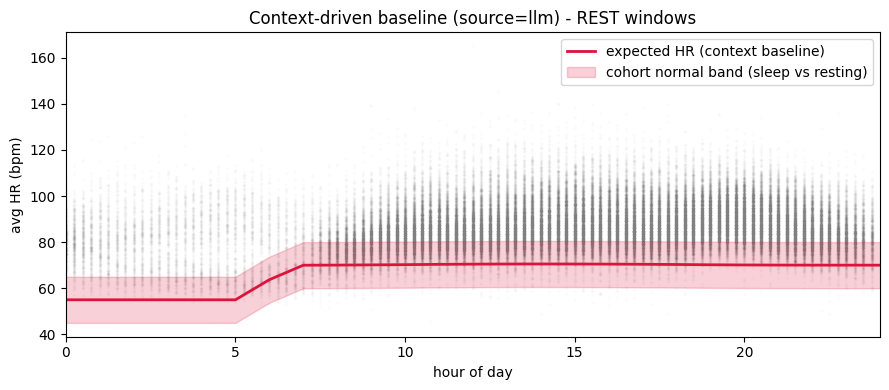

In [5]:
import matplotlib.pyplot as plt

rest = ep[~ep["is_workout"]].dropna(subset=["avg_hr"]).copy()
rest["t_hour"] = rest["datetime"].dt.hour + rest["datetime"].dt.minute / 60
byh = rest.assign(h=rest["t_hour"].round().astype(int)).groupby("h").agg(
    exp=("expected_hr", "mean"), lo=("band_lo", "mean"), hi=("band_hi", "mean"))

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(rest["t_hour"], rest["avg_hr"], s=2, alpha=0.02, color="gray")
ax.plot(byh.index, byh["exp"], color="crimson", lw=2, label="expected HR (context baseline)")
ax.fill_between(byh.index, byh["lo"], byh["hi"], color="crimson", alpha=0.2,
                label="cohort normal band (sleep vs resting)")
ax.set(xlabel="hour of day", ylabel="avg HR (bpm)", xlim=(0, 24),
       title=f"Context-driven baseline (source={base.source}) - REST windows")
ax.legend(); plt.tight_layout(); plt.show()

### Standard Definitions per episode -> `standard_definitions.parquet`
For **every** episode (rest and workout) save `expected_hr`, `band_lo/hi`, and the
signed `deviation_z` (unchanged interface for Part B + File 4), plus the context-native
`sub_range` / `deviation_ctx` / `direction` / `is_anomaly_context`. `deviation_z` also
becomes a GCN node feature in Part B and the baseline reference in File 4.

In [6]:
ep["t_hour"] = ep["datetime"].dt.hour + ep["datetime"].dt.minute / 60   # used by Part B features

STD_PATH = os.path.join(PROC_DIR, "standard_definitions.parquet")
ep[["node_id", "datetime", "avg_hr", "expected_hr", "band_lo", "band_hi",
    "deviation_z", "is_workout", "sub_range", "deviation_ctx", "direction",
    "is_anomaly_context", "weather_temp", "weather_humidity", "weather_shift",
    "lifestyle"]].to_parquet(STD_PATH, index=False)
print("saved", STD_PATH)
print(ep["deviation_z"].describe().round(2))

saved C:\Project\Apple Health Data\data\processed\standard_definitions.parquet
count    104565.00
mean          1.65
std           1.07
min          -5.02
25%           0.95
50%           1.52
75%           2.29
max           9.50
Name: deviation_z, dtype: float64


## Part B - GCN-DOMINANT structural detector (optional, relational view)

In [7]:
# Assemble GCN node features via the shared module (structural + Part-A deviation_z;
# NO LLM anomaly labels). Same builder File 4 uses -> one feature definition.
import sys
NB_DIR = r"C:\Project\Apple Health Data\notebooks"
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)
from graph_model import build_node_features, structural_scores, TG_AVAILABLE  # noqa: E402

node = ep.sort_values("node_id").reset_index(drop=True)
Xg_feat, feat_cols = build_node_features(node)
print("GCN node features:", Xg_feat.shape, "cols:", feat_cols)

GCN node features: (104565, 22) cols: ['deviation_z', 'avg_hr', 'hrv_sdnn', 'n_samples', 'hour_sin', 'hour_cos', 'weather_temp', 'weather_humidity', 'act_cycle', 'act_rest', 'act_row', 'act_run', 'act_sleep', 'act_strength', 'act_unknown', 'act_walk', 'loc_home', 'loc_outdoor', 'loc_park', 'loc_unknown', 'loc_water', 'loc_work']


In [8]:
# Load the BKG edge index (built in File 2).
edge_table = pd.read_parquet(os.path.join(PROC_DIR, "edge_table.parquet"))
print("edges by type:", edge_table["edge_type"].value_counts().to_dict())
print("structural model:", "GCN-DOMINANT (torch_geometric present)" if TG_AVAILABLE
      else "torch_geometric missing -> would fall back to a labelled PCA proxy")

edges by type: {'similarity': 836520, 'temporal': 102644, 'context': 848}
structural model: GCN-DOMINANT (torch_geometric present)


In [9]:
# Train GCN-DOMINANT on the real graph and score nodes + edges (shared module).
edge_index = edge_table[["src", "dst"]].values.T
node_score, edge_score, STRUCT_METHOD = structural_scores(
    Xg_feat, edge_index, epochs=150, alpha=0.7, seed=0, verbose=True)
print("structural detector:", STRUCT_METHOD)

epoch  30  attr=0.7966  struct=1.0643
epoch  60  attr=0.6350  struct=1.0318
epoch  90  attr=0.5603  struct=1.0154
epoch 120  attr=0.5197  struct=1.0008
epoch 150  attr=0.4952  struct=0.9926
structural detector: GCN-DOMINANT


structural detector: GCN-DOMINANT


In [10]:
node["node_anomaly_score"] = node_score
edge_table = edge_table.copy()
edge_table["edge_anomaly_score"] = edge_score

node[["node_id", "datetime", "node_anomaly_score"]].to_parquet(
    os.path.join(PROC_DIR, "node_anomaly_scores.parquet"), index=False)
edge_table.to_parquet(os.path.join(PROC_DIR, "edge_anomaly_scores.parquet"), index=False)
print("saved node & edge anomaly scores")
print("top-5 anomalous nodes:")
print(node.nlargest(5, "node_anomaly_score")[
    ["datetime", "avg_hr", "deviation_z", "activity", "location_type", "node_anomaly_score"]]
    .to_string(index=False))

saved node & edge anomaly scores
top-5 anomalous nodes:
                 datetime     avg_hr  deviation_z activity location_type  node_anomaly_score
2022-08-10 12:30:00+09:30  77.646341    -4.823577      run          work          793.190857
2022-03-01 09:30:00+10:30  83.926829    -4.404878      run       unknown          781.965637
2022-08-16 22:45:00+09:30  75.103448    -4.993103      run          work          780.128113
2022-03-01 09:15:00+10:30  84.916450    -4.338903      run       unknown          778.939819
2022-06-22 21:15:00+09:30 107.492958    -2.833803      run          work          762.654724


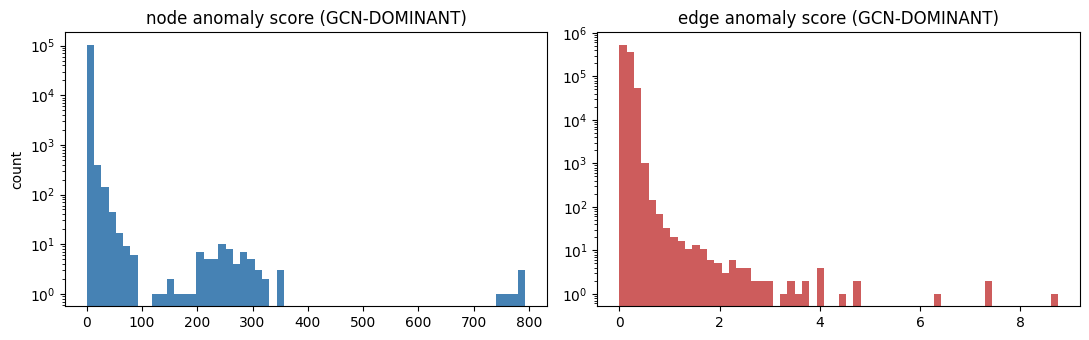

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(node["node_anomaly_score"], bins=60, color="steelblue")
ax[0].set(title=f"node anomaly score ({STRUCT_METHOD})", ylabel="count", yscale="log")
ax[1].hist(edge_table["edge_anomaly_score"], bins=60, color="indianred")
ax[1].set(title=f"edge anomaly score ({STRUCT_METHOD})", yscale="log")
plt.tight_layout(); plt.show()

## File 3 output summary

Written to `data/processed/`:
- `standard_definitions.parquet` - `expected_hr`, `band_lo/hi`, `deviation_z` + context
  columns (`sub_range`, `deviation_ctx`, `direction`, `is_anomaly_context`) per episode (Part A)
- `node_anomaly_scores.parquet` - GCN node scores (Part B, if `torch_geometric` present)
- `edge_anomaly_scores.parquet` - GCN edge scores (Part B, if `torch_geometric` present)

**Guardrail check:** the baseline is a per-cohort reference emitted by the LLM/prior
(`establish_baseline`), not a personal curve; the LLM set only the reference ranges while
a deterministic detector measured per-episode deviation (no circularity); missing context
widened the band rather than crashing; the GCN used no LLM anomaly labels and produced
both node and edge scores.

Next: **File 4** evaluates these against synthetic ground truth and compares the
GCN-structural view with an independent LLM-semantic view.